# Importing Libraries

In [2]:
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle
from sklearn.linear_model import Ridge , Lasso

# Loading Data

In [3]:
data = pd.read_csv('farm_yield_dataset.xlsx - Sheet1.csv')
df = data.copy()

# Exploring Data

In [4]:
df.head()

,farm_id,fertilizer_kg_per_hectare,rainfall_mm,soil_ph,farm_size_hectares,years_farming_experience,crop_type,irrigation_type,region,yield_tons_per_hectare
0,F1211,225.0,223.3,6.31,8.5,32,Wheat,Flood,Upper Egypt,6.61
1,F1313,146.0,NaN,6.82,11.9,11,Corn,Flood,Sinai,9.35
2,F1304,327.3,1310.9,6.30,29.9,1,Barley,Flood,Upper Egypt,0.48
3,F1113,224.3,708.4,6.35,9.4,31,WHEAT,Drip,Upper Egypt,7.76
4,F1251,331.0,694.4,7.63,3.3,18,Wheat,Flood,Delta,0.79


In [5]:
print(f"Rows: {df.shape[0]} , Cols: {df.shape[1]}")

Rows: 343 , Cols: 10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   farm_id                    343 non-null    object 
 1   fertilizer_kg_per_hectare  343 non-null    float64
 2   rainfall_mm                329 non-null    float64
 3   soil_ph                    333 non-null    float64
 4   farm_size_hectares         343 non-null    float64
 5   years_farming_experience   343 non-null    int64  
 6   crop_type                  343 non-null    object 
 7   irrigation_type            343 non-null    object 
 8   region                     343 non-null    object 
 9   yield_tons_per_hectare     343 non-null    float64
dtypes: float64(5), int64(1), object(4)
memory usage: 26.9+ KB


In [7]:
df.describe()

,fertilizer_kg_per_hectare,rainfall_mm,soil_ph,farm_size_hectares,years_farming_experience,yield_tons_per_hectare
count,343.000000,329.000000,333.000000,343.000000,343.000000,343.000000
mean,201.935569,737.271733,6.368889,17.774344,16.685131,6.989184
std,224.021842,222.360286,0.869660,9.815529,10.142839,3.573029
min,12.700000,150.000000,4.300000,-5.000000,0.000000,0.200000
25%,96.100000,586.400000,5.780000,10.950000,8.000000,4.955000
50%,190.100000,744.300000,6.410000,16.200000,16.000000,7.870000
75%,286.300000,872.400000,6.930000,22.950000,25.000000,9.580000
max,3850.000000,1321.500000,8.700000,53.900000,34.000000,12.510000


In [8]:
df.describe(include='O')

,farm_id,crop_type,irrigation_type,region
count,343,343,343,343
unique,340,9,3,3
top,F1129,Wheat,Drip,Delta
freq,2,131,132,170


In [9]:
df['crop_type'].unique()

array(['Wheat', 'Corn', 'Barley', 'WHEAT', 'CORN', ' wheat ', 'Rice',
       'RICE', ' rice '], dtype=object)

In [10]:
df['irrigation_type'].unique()

array(['Flood', 'Drip', 'Sprinkler'], dtype=object)

In [11]:
df['region'].unique()

array(['Upper Egypt', 'Sinai', 'Delta'], dtype=object)

In [12]:
df.isnull().sum()

farm_id                       0
fertilizer_kg_per_hectare     0
rainfall_mm                  14
soil_ph                      10
farm_size_hectares            0
years_farming_experience      0
crop_type                     0
irrigation_type               0
region                        0
yield_tons_per_hectare        0
dtype: int64

In [13]:
duplicated = df.duplicated().sum()
duplicated

np.int64(3)

In [14]:
df[df.duplicated(keep=False)]

,farm_id,fertilizer_kg_per_hectare,rainfall_mm,soil_ph,farm_size_hectares,years_farming_experience,crop_type,irrigation_type,region,yield_tons_per_hectare
8,F1188,286.3,825.8,6.41,16.9,17,Wheat,Flood,Upper Egypt,3.09
61,F1188,286.3,825.8,6.41,16.9,17,Wheat,Flood,Upper Egypt,3.09
167,F1129,227.4,986.8,7.30,23.4,4,Wheat,Flood,Sinai,6.80
188,F1129,227.4,986.8,7.30,23.4,4,Wheat,Flood,Sinai,6.80
291,F1114,75.4,822.3,6.33,22.3,3,Wheat,Flood,Delta,8.01
321,F1114,75.4,822.3,6.33,22.3,3,Wheat,Flood,Delta,8.01


## Checking Outliers

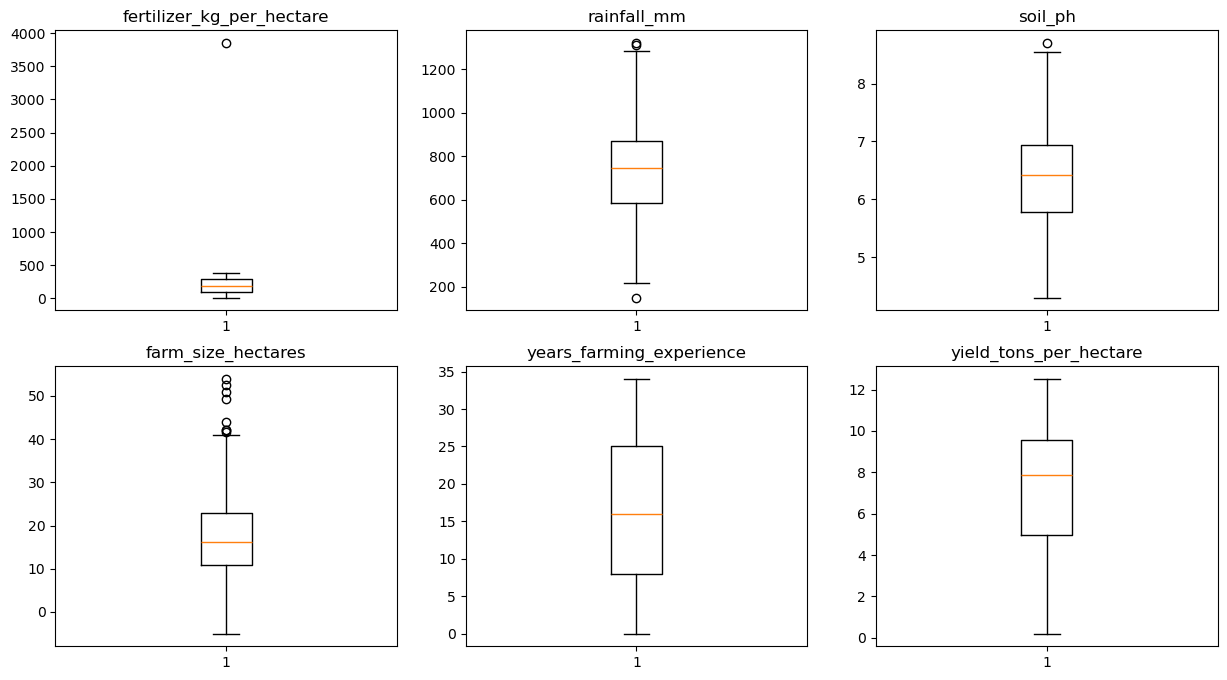

In [15]:
columns = ['fertilizer_kg_per_hectare', 'rainfall_mm','soil_ph', 'farm_size_hectares','years_farming_experience','yield_tons_per_hectare']
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.ravel()  
for ax , col in zip(axes,columns):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.show()

##### We need to handle the detected outliers in the features so that the model can learn the underlying patterns more effectively and reduce the impact of noise

# Data Cleaning & Preparation

#### Handling Negative Values

In [16]:
df['farm_size_hectares']=abs(df['farm_size_hectares'])

### Handling The Values of Corn Feature

In [17]:
df['crop_type'] = df['crop_type'].str.strip()

In [18]:
df['crop_type'] = df['crop_type'].str.capitalize()

In [19]:
df['crop_type'].unique()

array(['Wheat', 'Corn', 'Barley', 'Rice'], dtype=object)

## Dropping Duplicates

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

## Handling Outliers In Features

In [22]:
def capping_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if(outliers_before>0):
         df[col] = df[col].clip(lower_bound, upper_bound)
         outliers_after = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
         print(f"{col}: Outliers Before = {outliers_before}  , Outliers After = {outliers_after} ")

In [23]:
for col in columns:
    capping_outliers(df,col)

fertilizer_kg_per_hectare: Outliers Before = 1  , Outliers After = 0 
rainfall_mm: Outliers Before = 3  , Outliers After = 0 
soil_ph: Outliers Before = 1  , Outliers After = 0 
farm_size_hectares: Outliers Before = 8  , Outliers After = 0 


## Handling Missing Values

In [24]:
df['rainfall_mm'] = df['rainfall_mm'].fillna(df['rainfall_mm'].mean())

In [25]:
df['soil_ph'] = df['soil_ph'].fillna(df['soil_ph'].mean())

In [26]:
df.isnull().sum()

farm_id                      0
fertilizer_kg_per_hectare    0
rainfall_mm                  0
soil_ph                      0
farm_size_hectares           0
years_farming_experience     0
crop_type                    0
irrigation_type              0
region                       0
yield_tons_per_hectare       0
dtype: int64

# Data Preprocessing

## Label Encoding

In [27]:
encoders = {}
categorical_cols = ['crop_type', 'irrigation_type', 'region']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

## Correlation 

In [28]:
columns2 =  ['fertilizer_kg_per_hectare', 'rainfall_mm','soil_ph',
             'farm_size_hectares','years_farming_experience','crop_type','irrigation_type','region']

C:\Users\C2D\AppData\Local\Temp\ipykernel_28848\1331777969.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


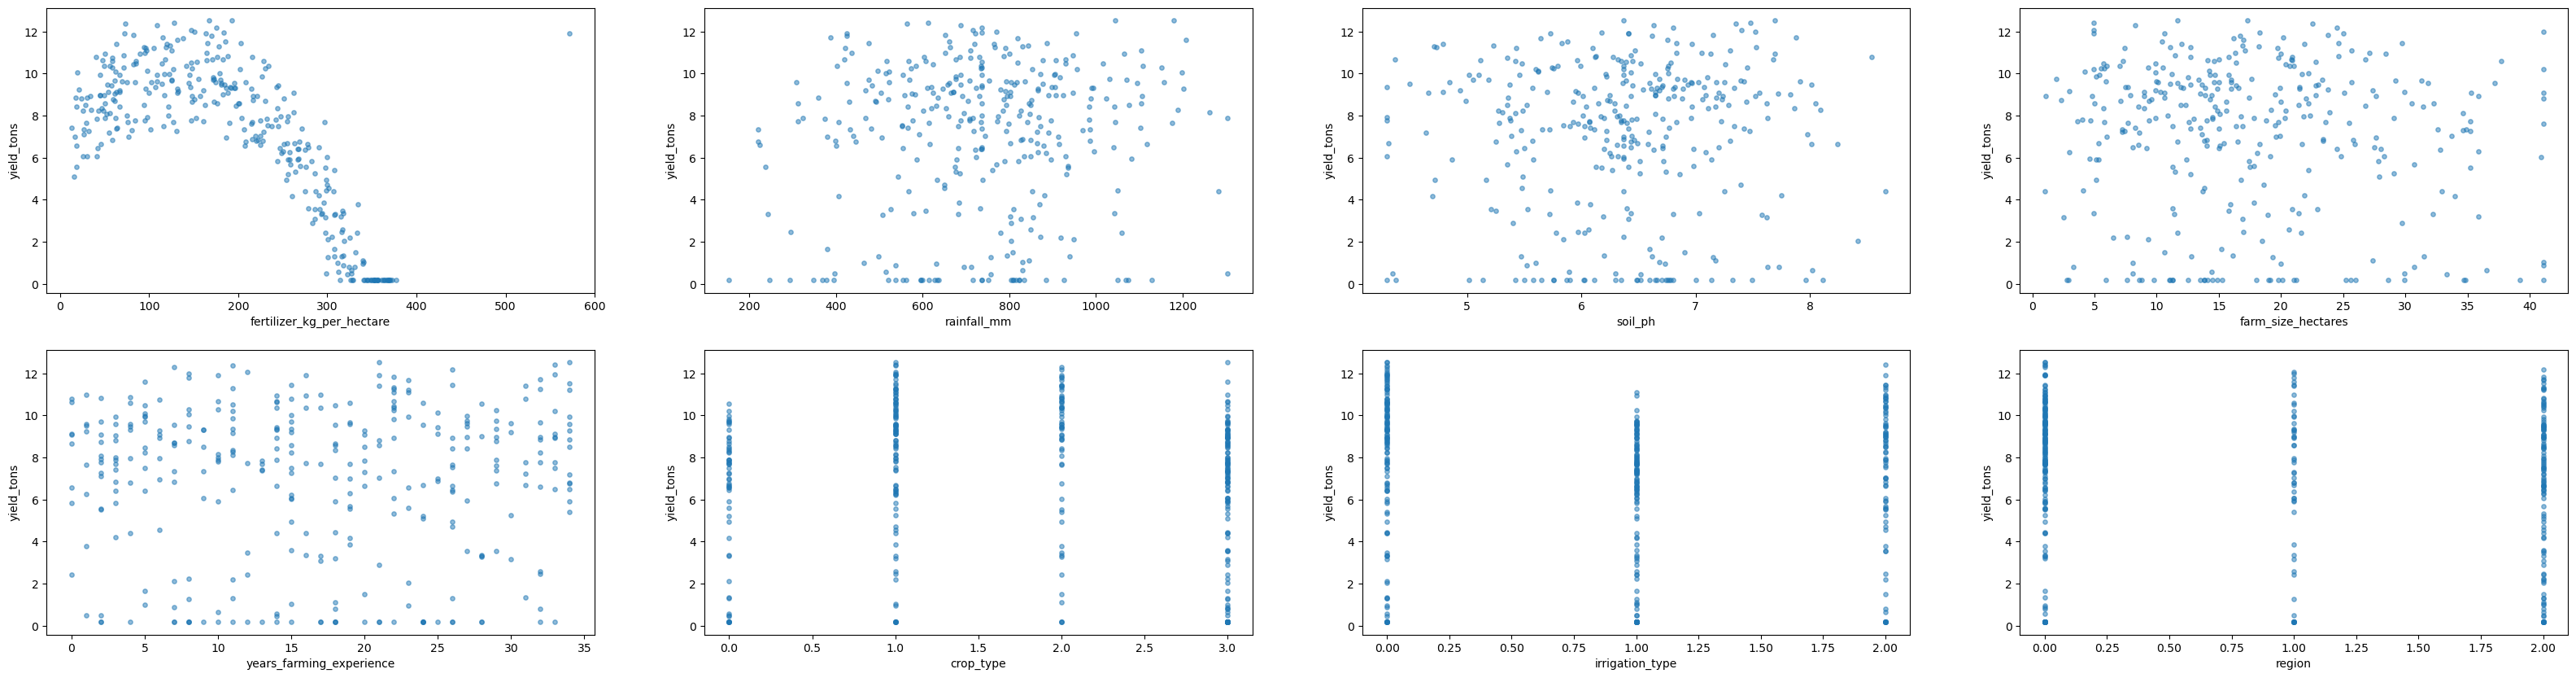

In [29]:
fig , axes = plt.subplots(2, 4 , figsize = (40,10))
axes = axes.ravel()  
for ax , col in zip(axes , columns2):
    ax.scatter(df[col], df['yield_tons_per_hectare'], alpha=0.5 , s=15)
    ax.set_xlabel(col)
    ax.set_ylabel('yield_tons')
fig.show()

##### - Among all the features, fertilizer_kg_per_hectare shows the most noticeable non-linear relationship with the target variable

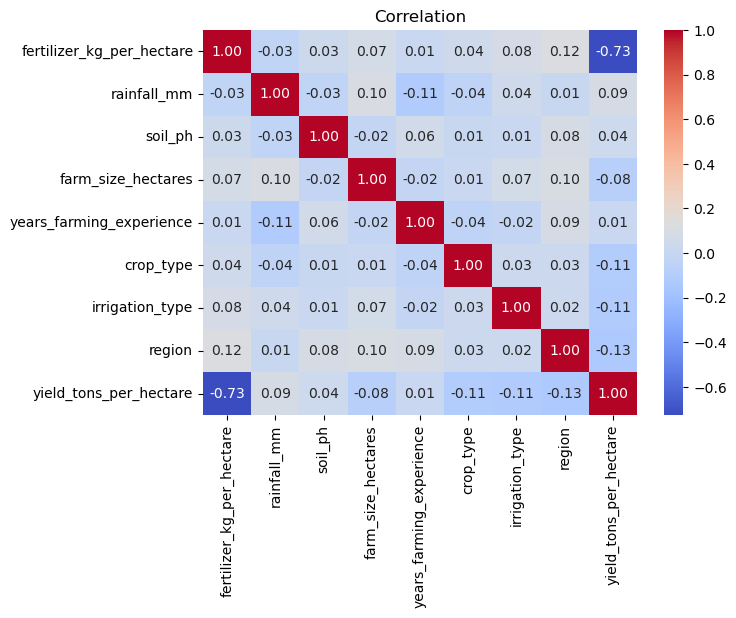

In [30]:
cor = df.drop('farm_id',axis=1).corr()
plt.figure(figsize=(7,5))
sns.heatmap(cor,annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation')
plt.show()

## Splitting Data

In [31]:
X = df.drop(['farm_id','yield_tons_per_hectare'],axis=1)
Y = df['yield_tons_per_hectare']

In [32]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [33]:
print(f"Training Rows : {X_train.shape[0]}")
print(f"Testing Rows : {X_test.shape[0]}")

Training Rows : 272
Testing Rows : 68


## Feature Scaling

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1- Linear Regression Model 

## Building Model

In [35]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Prediction

In [36]:
Y_pred_linear = linear_model.predict(X_test_scaled)
y_pred_train_linear = linear_model.predict(X_train_scaled)

## Evaluating Linear Model

In [37]:
def evaluate_model(model_name, y_train, y_train_pred, y_test, y_test_pred):
    mae = mean_absolute_error(y_test, y_test_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)

    print(f"{model_name}")
    print(f"MAE = {mae}")
    print(f"MSE (Train) = {mse_train}")
    print(f"MSE (Test) = {mse_test}")
    print(f"R2 Score = {r2}")

    return mae, mse_train, mse_test, r2

In [38]:
linear_mae, linear_mse_train, linear_mse_test, linear_r2 = evaluate_model('Linear Regression Model', Y_train, y_pred_train_linear, Y_test, Y_pred_linear)

Linear Regression Model
MAE = 1.9746020262475885
MSE (Train) = 5.973218256593211
MSE (Test) = 5.233620899845124
R2 Score = 0.5552589574088418


#####  - The training and testing MSE values are close, indicating that the model is not overfitting. but the R2 score of 0.555 shows that the model explains only 55.5% of the variance in the target, so we need to try another models that fit the variance of data for improvement

# Visualizing Model Prediction

C:\Users\C2D\AppData\Local\Temp\ipykernel_28848\501861351.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


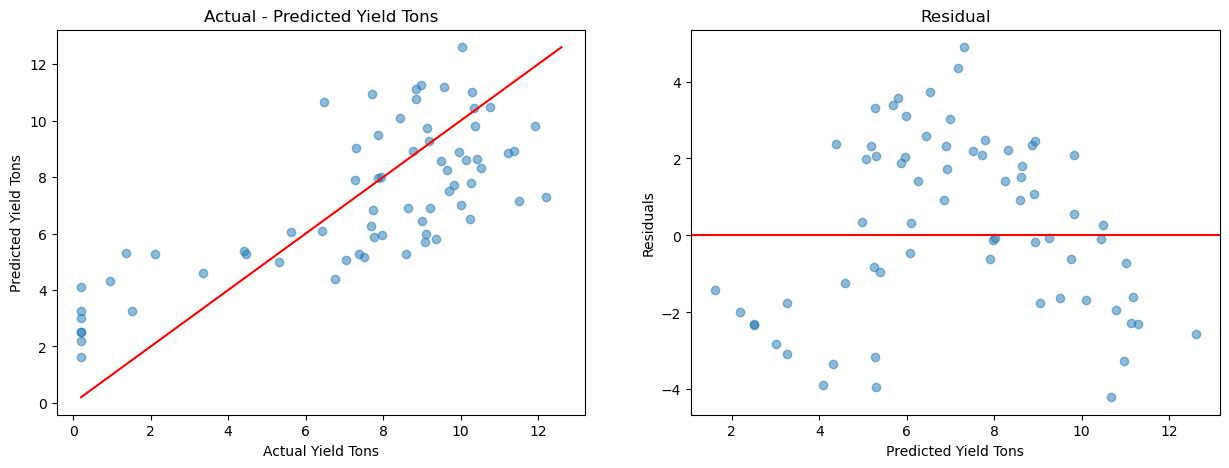

In [39]:
fig , axes = plt.subplots( 1, 2 ,figsize =(15,5))
axes[0].scatter(Y_test,Y_pred_linear, alpha = 0.5)
limits = [min(Y_test.min() , Y_pred_linear.min()) , max(Y_test.max() , Y_pred_linear.max())]
axes[0].plot(limits,limits , color='red')
axes[0].set_title('Actual - Predicted Yield Tons')
axes[0].set_xlabel('Actual Yield Tons')
axes[0].set_ylabel('Predicted Yield Tons')
residual = Y_test - Y_pred_linear
axes[1].scatter(Y_pred_linear,residual, alpha = 0.5)
axes[1].axhline(0 , color='red')
axes[1].set_title('Residual')
axes[1].set_xlabel('Predicted Yield Tons')
axes[1].set_ylabel('Residuals')
fig.show()

# 2- Polynomial Regression Model

## Building Model

In [40]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [41]:
Poly_model = LinearRegression()
Poly_model.fit(X_train_poly,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Prediction

In [42]:
Y_pred_poly = Poly_model.predict(X_test_poly)
Y_train_pred_poly = Poly_model.predict(X_train_poly)

## Evaluating Polynomial Model

In [43]:
Y_train_pred_poly = Poly_model.predict(X_train_poly)
MSE_Train_Poly = mean_squared_error(Y_train, Y_train_pred_poly)

In [44]:
poly_mae, poly_mse_train, poly_mse_test, poly_r2 = evaluate_model("Polynomial Regression Model", Y_train, Y_train_pred_poly, Y_test, Y_pred_poly)

Polynomial Regression Model
MAE = 1.478842760538988
MSE (Train) = 2.988419405071974
MSE (Test) = 3.010443136283819
R2 Score = 0.7441794801889678


In [45]:
MAE_Poly = mean_absolute_error(Y_test, Y_pred_poly)
MSE_Poly = mean_squared_error(Y_test, Y_pred_poly)
R2_Score_Poly = r2_score(Y_test, Y_pred_poly)
print('Polynomial Model (degree=2) : ')
print(f" MAE = {MAE_Poly}")
print(f" MSE(Train) = {MSE_Train_Poly}")
print(f" MSE(Test) = {MSE_Poly}")
print(f" R2 Score = {R2_Score_Poly}")


Polynomial Model (degree=2) : 
 MAE = 1.478842760538988
 MSE(Train) = 2.988419405071974
 MSE(Test) = 3.010443136283819
 R2 Score = 0.7441794801889678


##### - Based on the R2 score of 0.744, we can conclude that the polynomial regression model (degree = 2) provides a better fit to the data than the linear regression model.

# Visualizing Polynomial Model Prediction

C:\Users\C2D\AppData\Local\Temp\ipykernel_28848\1137064282.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


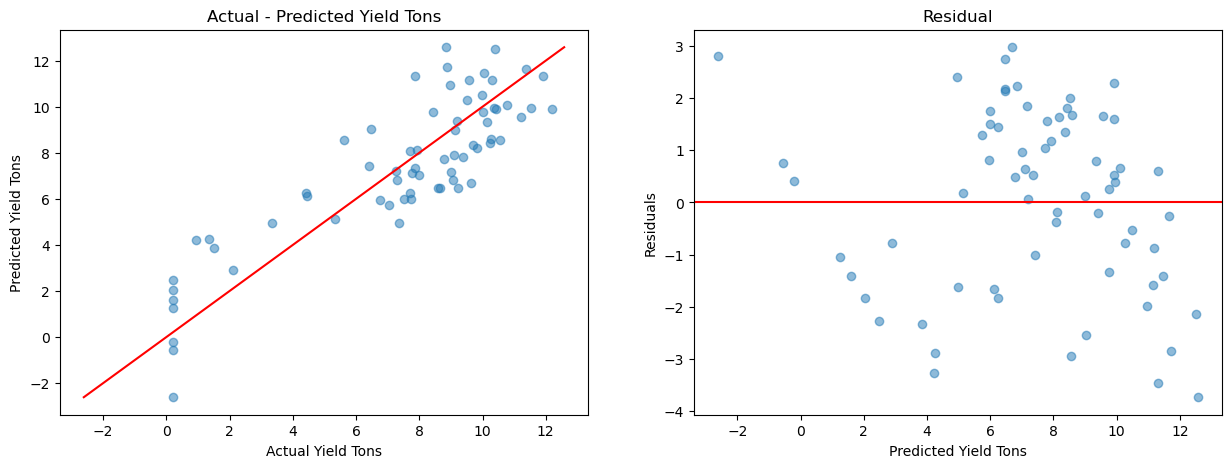

In [46]:
fig , axes = plt.subplots( 1, 2 ,figsize =(15,5))
axes[0].scatter(Y_test,Y_pred_poly, alpha = 0.5)
limits = [min(Y_test.min() , Y_pred_poly.min()) , max(Y_test.max() , Y_pred_poly.max())]
axes[0].plot(limits,limits , color='red')
axes[0].set_title('Actual - Predicted Yield Tons')
axes[0].set_xlabel('Actual Yield Tons')
axes[0].set_ylabel('Predicted Yield Tons')
residual = Y_test - Y_pred_poly
axes[1].scatter(Y_pred_poly,residual, alpha = 0.5)
axes[1].axhline(0 , color='red')
axes[1].set_title('Residual')
axes[1].set_xlabel('Predicted Yield Tons')
axes[1].set_ylabel('Residuals')
fig.show()

# Applying Regularization On Polynomial Model 
- To see if we still can minimize the test error and achieve higher prediction accuracy on unseen data.

## 1- Lasso

##### Trying Different Alphas

In [47]:
alphas = [0.001, 0.01, 0.1, 1, 7, 10, 50,100]
for a in alphas:
    lasso = Lasso(alpha = a, max_iter=100000)
    lasso.fit(X_train_poly,Y_train)
    mse_lasso_test = mean_squared_error(Y_test,lasso.predict(X_test_poly))
    print(f"Alpha {a}   ->      Test MSE = {mse_lasso_test}")

Alpha 0.001   ->      Test MSE = 2.9927072090702294
Alpha 0.01   ->      Test MSE = 2.85051277875535
Alpha 0.1   ->      Test MSE = 2.4626147475505324
Alpha 1   ->      Test MSE = 5.7800012336599345
Alpha 7   ->      Test MSE = 12.040953784602078
Alpha 10   ->      Test MSE = 12.040953784602078
Alpha 50   ->      Test MSE = 12.040953784602078
Alpha 100   ->      Test MSE = 12.040953784602078


##### Applying Lasso With Best Alpha

In [48]:
lasso2= Lasso(alpha=0.1 )
lasso2.fit(X_train_poly,Y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


##### Prediction

In [49]:
y_pred_lasso2 = lasso2.predict(X_test_poly)
y_pred_lasso2_train = lasso2.predict(X_train_poly)

##### Evaluation

In [50]:
lasso_mae, lasso_mse_train, lasso_mse_test, lasso_r2 = evaluate_model("Lasso Regularization :", Y_train, y_pred_lasso2_train, Y_test, y_pred_lasso2)

Lasso Regularization :
MAE = 1.3587002797229562
MSE (Train) = 3.289491945266679
MSE (Test) = 2.4626147475505324
R2 Score = 0.790732674130372


## 2- Using Ridge

##### Trying Different Alphas

In [51]:
print("ٌRidge test MSE:")
for a in [0.001, 0.01, 0.1, 1, 7, 10, 50,100]:
    ridge = Ridge(alpha=a, max_iter=100000)
    ridge.fit(X_train_poly, Y_train)
    test_mse = mean_squared_error(Y_test, ridge.predict(X_test_poly))
    print(f"  alpha={a}   ->   test MSE {test_mse:.3f}")

ٌRidge test MSE:
  alpha=0.001   ->   test MSE 3.010
  alpha=0.01   ->   test MSE 3.010
  alpha=0.1   ->   test MSE 3.009
  alpha=1   ->   test MSE 2.999
  alpha=7   ->   test MSE 2.944
  alpha=10   ->   test MSE 2.924
  alpha=50   ->   test MSE 2.952
  alpha=100   ->   test MSE 3.334


##### Applying Ridge With Best Alpha

In [52]:
ridge = Ridge(alpha=7)
ridge.fit(X_train_poly,Y_train)

,alpha,7
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


##### Prediction

In [53]:
Y_pred_ridge = ridge.predict(X_test_poly)
Y_pred_ridge_train = ridge.predict(X_train_poly)

##### Evaluation

In [54]:
ridge_mae, ridge_mse_train, ridge_mse_test, ridge_r2 = evaluate_model('Ridge Regularization :', Y_train, Y_pred_ridge_train, Y_test, Y_pred_ridge)

Ridge Regularization :
MAE = 1.4594220095578345
MSE (Train) = 2.995965189122394
MSE (Test) = 2.943800032686406
R2 Score = 0.749842657546025


## Comparing Models

In [56]:
models_evaluation = {
    "Model": ["Linear Regression", "Polynomial Regression (Degree=2)", "Lasso Regularization", "Ridge Regularization"],
    "MAE": [linear_mae , poly_mae , lasso_mae ,ridge_mae],
    "MSE(Test)": [linear_mse_test , poly_mse_test, lasso_mse_test , ridge_mse_test],
    "MSE(Train)": [ linear_mse_train, poly_mse_train, lasso_mse_train, ridge_mse_train],
    "R2 Score": [linear_r2, poly_r2, lasso_r2, ridge_r2]}
results = pd.DataFrame(models_evaluation)
results = results.round(4)
results

,Model,MAE,MSE(Test),MSE(Train),R2 Score
0,Linear Regression,1.9746,5.2336,5.9732,0.5553
1,Polynomial Regression (Degree=2),1.4788,3.0104,2.9884,0.7442
2,Lasso Regularization,1.3587,2.4626,3.2895,0.7907
3,Ridge Regularization,1.4594,2.9438,2.9960,0.7498


### Conclusion:
- Linear Regression was not sufficient for modeling the dataset.
- Polynomial Regression captured the non-linear patterns and significantly improved performance.
- Lasso regularization provided the best balance between model complexity and prediction accuracy.
- Ridge regularization improved the Polynomial model but was less effective than Lasso.
- The best model for this dataset is Polynomial Regression (Degree = 2) with Lasso Regularization.

# Saving Models

#### Saving Best Model ( Polynomial (degree=2) With Lasso Regularization )

In [57]:
all = {
    'Encoders' : encoders,
    'Scaler' : scaler,
    'linear_model' : linear_model,
    'Polynomial Features' : poly,
    'Lasso' : lasso2
}

In [58]:
with open('lasso_model.pkl','wb') as file:
    pickle.dump(all,file)